IF YOU ARE INTERESTED IN LEARNING TO CODE: PLEASE GO THROUGH THEN FOLLOWING LINKS!

PYTHON:
- https://www.w3schools.com/python/

GITHUB TUTORIAL (version control, easiest way to share and collaborate on code!):
- https://www.youtube.com/watch?v=tRZGeaHPoaw


LIBRARIES WE USE


- numpy: Library for numerical computing
https://www.w3schools.com/python/numpy/default.asp


- lgpio: library for communicating with general input output pins, and uses communication interfaces such as I2C to communicate with other devices. 
https://abyz.me.uk/lg/py_lgpio.html

    
- openCV: Library for image and video manipulation, allows real time processing and converting images into matrices. 
https://www.kaggle.com/code/talhabu/opencv-tutorial-from-basic-to-advanced

LAST YEARS CODE AND ALGORITHM

- Example of last years reaction: ./7_2ST_12_2H20T2.mp4

- which pixel values to read

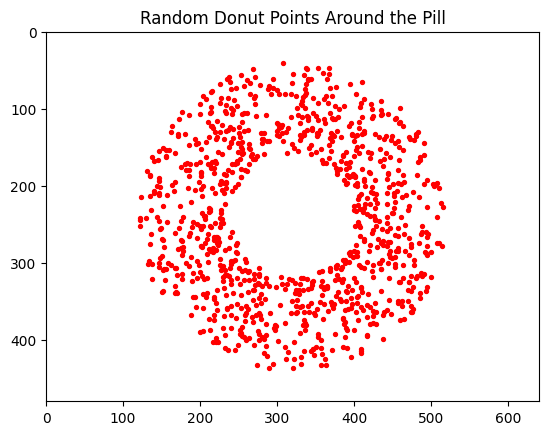

In [30]:

import matplotlib.pyplot as plt
import math
import random

def random_donut_points(cx, cy, r_inner, r_outer, n_points=100):
    """
    Generate n_points uniformly distributed in a 'donut' between
    r_inner and r_outer from the center (cx, cy).
    """
    points = []
    for _ in range(n_points):
        # Pick a random radius between r_inner and r_outer
        r = random.uniform(r_inner, r_outer)
        # Pick a random angle in [0, 2π)
        theta = random.uniform(0, 2*math.pi)
        # Convert polar -> cartesian
        x = cx + r * math.cos(theta)
        y = cy + r * math.sin(theta)
        points.append((x, y))
    return points

# Example usage:
width, height = 640, 480  # Example image size
cx, cy = width / 2, height / 2  # Assume pill is at center
r_inner = 80   # Approx radius to exclude around pill
r_outer = 200  # Outer radius for the plate

# Generate random points in the 'donut'
points = random_donut_points(cx, cy, r_inner, r_outer, n_points=1000)

# Plot
plt.figure()
plt.scatter(*zip(*points), c='red', s=8)
plt.xlim(0, width)
plt.ylim(height, 0)  # Flip y-axis if you want image-style coordinates
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Random Donut Points Around the Pill")
plt.show()

ALGORITHM LAST YEAR, general functions:
- sliding window using deque (new value arrives, oldest value exits)
- take average of the window, check if it meets initial thresholds (to reduce misreads from reaction noise)
- compute standard deviations (checking variability of the reaction)
- once the average standard deviation is under a certain threshold we stop the reaction

In [20]:
import cv2
import numpy as np
from collections import deque
import time
#from picamera2 import Picamera2, Preview
#from libcamera import controls
import threading
import os


# Threading event
operation_active = threading.Event()
camera_lock = threading.Lock()  # Only allows one thread to access the camera

# Constants for frame center and offset
CENTER_X, CENTER_Y = 600 // 2, 500 // 2
OFFSET = 20  # Half of the side length of the 100x100 area

def random_donut_points(cx, cy, r_inner, r_outer, n_points=100, frame_shape=None):
    """
    Generate n_points uniformly distributed in a 'donut' between
    r_inner and r_outer from the center (cx, cy).
    """
    points = []
    h, w = frame_shape if frame_shape is not None else (None, None)
    for _ in range(n_points):
        # Pick a random radius between r_inner and r_outer
        r = random.uniform(r_inner, r_outer)
        # Pick a random angle in [0, 2π)
        theta = random.uniform(0, 2*math.pi)
        # Convert polar -> cartesian
        x = cx + r * math.cos(theta)
        y = cy + r * math.sin(theta)

        if frame_shape is None or (0 <= x < w and 0 <= y < h):
            points.append((x, y))
    return points


def measure_color_change(frame, pixels):
    """Extract RGB values for specified pixels and return their average."""
    color_values = []
    for x, y in pixels:
        x = int(x)
        y = int(y)
        if 0 <= y < frame.shape[0] and 0 <= x < frame.shape[1]:
            color_values.extend(frame[y, x])
    if not color_values:
        return 0
    return np.mean(color_values)

def initialize_video(video_path):
    """Initialize a VideoCapture object from the given path."""
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found: {video_path}")
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Could not open video file: {video_path}")
    print(f"[INFO] Successfully opened video: {video_path}")
    return cap

def capture_frame(cap):
    """Safely capture a single frame and return RGB grayscale version."""
    ret, frame = cap.read()
    if not ret or frame is None:
        print("[INFO] End of video or failed frame capture.")
        return None
    try:
        frame_bw = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_rgb = cv2.cvtColor(frame_bw, cv2.COLOR_GRAY2RGB)
        return frame_rgb
    except Exception as e:
        print(f"[ERROR] Failed cvtColor: {e}")
        return None

def calculate_offset(temp_array):
    """Calculate baseline offset from mean of temp array."""
    base_val = np.mean(temp_array)
    return base_val - 60

def process_frame(cap, pixels_to_measure, temp_array, stdev_array, offset, frame_size, start_time):
    """Process one frame and check for stabilization."""
    frame_rgb = capture_frame(cap)
    if frame_rgb is None:
        return False  # End of video or capture failure

    mean_color_value = measure_color_change(frame_rgb, pixels_to_measure)
    temp_array.append(mean_color_value)

    if len(temp_array) == temp_array.maxlen:
        if frame_size == (temp_array.maxlen - 1):
            offset = calculate_offset(temp_array)

        adjusted_mean = np.mean(temp_array) - offset
        if adjusted_mean > 80:
            stdev = np.std(np.array(temp_array) - offset)
            stdev_array.append(stdev)

            if stdev < 1.5:
                elapsed_time = time.time() - start_time
                print(f"[RESULT] Reaction stabilized at frame {frame_size}")
                print(f"[RESULT] Elapsed time (assuming 30 fps): {frame_size/30} s")
                return False

    return True

def running_alg(video_path):
    """Run main algorithm on given video."""
    with camera_lock:
        cap = initialize_video(video_path)
        ret, frame = cap.read()
        h, w = frame.shape[:2]
        temp_array = deque(maxlen=500)
        stdev_array = []
        frame_size = 0
        offset = 0
        start_time = time.time()
        width, height = 640, 480  # Example image size
        cx, cy = width / 2, height / 2  # Assume pill is at center
        r_inner = 80   # Approx radius to exclude around pill
        r_outer = 200 

        pixels_to_measure = random_donut_points(cx, cy, r_inner, r_outer, n_points=100, frame_shape=(h, w))

        operation_active.set()

        try:
            while operation_active.is_set():
                if not process_frame(cap, pixels_to_measure, temp_array, stdev_array, offset, frame_size, start_time):
                    break
                frame_size += 1
        finally:
            cap.release()
            cv2.destroyAllWindows()
            operation_active.clear()
            print("[INFO] Processing complete.")

In [21]:
running_alg('7_2ST_12_2H20T2.mp4')

[INFO] Successfully opened video: 7_2ST_12_2H20T2.mp4
[RESULT] Reaction stabilized at frame 2071
[RESULT] Elapsed time (assuming 30 fps): 69.03333333333333 s
[INFO] Processing complete.


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from collections import deque

def graph_reaction(video_path, window_size):
    """
    Analyze the video and graph the mean grayscale intensity per frame.
    This helps visualize the color/intensity change (reaction curve) over time.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"[ERROR] Could not open video: {video_path}")
        return

    # open the video
    ret, frame = cap.read()
    if not ret:
        print("[ERROR] Could not read first frame.")
        return

    h, w = frame.shape[:2]
    cx, cy = w / 2, h / 2
    r_inner, r_outer = 80, 200
    n_points = 100

    # generate the sample points
    points = []
    for _ in range(n_points):
        r = random.uniform(r_inner, r_outer)
        theta = random.uniform(0, 2 * math.pi)
        x = int(cx + r * math.cos(theta))
        y = int(cy + r * math.sin(theta))
        if 0 <= x < w and 0 <= y < h:
            points.append((x, y))

    print(f"[INFO] Generated {len(points)} sampling points.")

    window_size = window_size
    temp_array = deque(maxlen=window_size)
    mean_series = []     # rolling mean of temp_array
    stdev_series = []    # rolling std of temp_array
    frame_means = []     # raw mean intensity per frame
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        pixel_vals = np.array([frame_gray[y, x] for (x, y) in points])
        mean_color_value = np.mean(pixel_vals)
        temp_array.append(mean_color_value)
        frame_means.append(mean_color_value)

        if len(temp_array) >= 2:  # only compute once we have enough data
            current_mean = np.mean(temp_array)
            current_std = np.std(temp_array)
        else:
            current_mean = 0
            current_std = 0

        mean_series.append(current_mean)
        stdev_series.append(current_std)
        frame_idx += 1

    cap.release()
    print(f"[INFO] Processed {frame_idx} frames.")
    print(f"[INFO] Rolling window size: {window_size}")

    frames = np.arange(1, len(mean_series) + 1)

    # --- Plot rolling mean ---
    plt.figure(figsize=(10, 4))
    plt.plot(frames, mean_series, color='blue', linewidth=1.5)
    plt.title("Reaction Curve — Rolling Mean Intensity)")
    plt.xlabel("Frame Number")
    plt.ylabel("Rolling Mean Intensity")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # --- Plot rolling std deviation ---
    plt.figure(figsize=(10, 4))
    plt.plot(frames, stdev_series, color='red', linewidth=1.5)
    plt.title("Reaction Stability — Rolling Std Deviation")
    plt.xlabel("Frame Number")
    plt.ylabel("Rolling Std Deviation")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

[INFO] Generated 100 sampling points.
[INFO] Processed 3682 frames.
[INFO] Rolling window size: 500


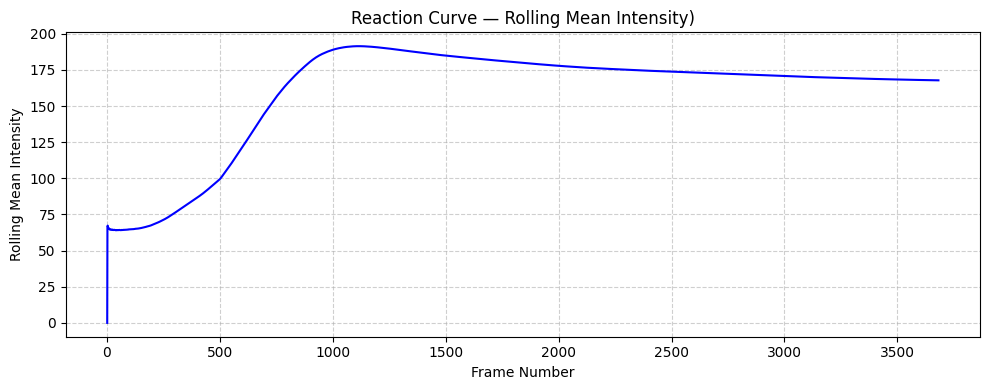

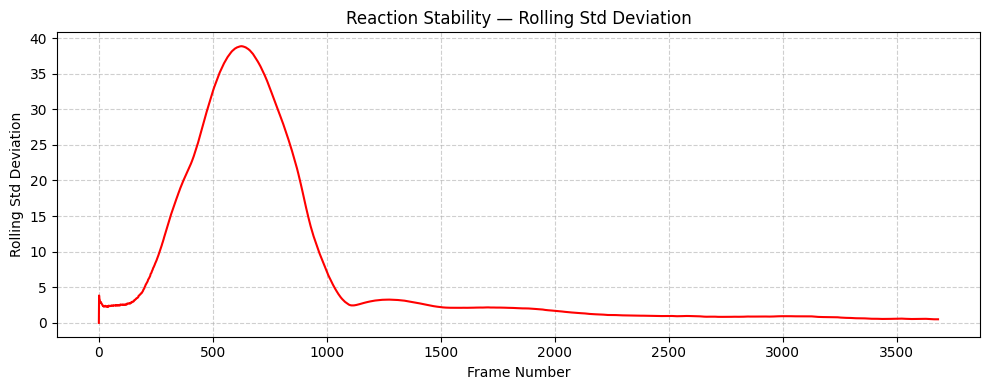

In [26]:
graph_reaction('7_2ST_12_2H20T2.mp4', 500)

GENERAL CODE BETWEEN GPIO DEVICES FROM LAST YEAR:
- uses gpiozero library
- we will not be using this library, we are switching to lgpio

In [ ]:
from gpiozero import LED, Button, DigitalOutputDevice, Servo
import alg
import time
import threading
import cv2
from picamera2 import Picamera2, Preview
import numpy as np
import sys
import i2cprotocol
#from gpiozero import Servo
#This is a test to see if everyone sees
#initializing constants
'''
TODOS:
Need a function for magnetic stirer:
specs: Needs a pin to output a HIGH signal 3 seconds After the motor turns (a new pin is needed)

Need a function for stepper motor:
Specs: Need a new motor function that works with a stepper motor. Research how to configure a stepper motor
This function will replace the old motor function, do not delete old motor function but update it (Can use current motor pins)

Need to call sendMessage somehow, but first need to verify is this function is working. *TESTS REQUIRED*

'''
LED_PIN = 6
STOP_SIGNAL_PIN = 16
BUTTON_PIN = 22
RESET_PIN = 26
forwardPin = 17
backwardPin = 27
delayTime = 2
motor_opened = False

#2,3
# Pin that connects the LED
LED_PIN2 = 10

#Pin that connects the stirrer
STIRRER_PIN = 24

#setup
stop_signal = DigitalOutputDevice(STOP_SIGNAL_PIN)
stirrer = DigitalOutputDevice(STIRRER_PIN)
button = Button(BUTTON_PIN, pull_up=True)
reset_button = Button(RESET_PIN, pull_up=True)
forward_motor = DigitalOutputDevice(forwardPin)
backward_motor = DigitalOutputDevice(backwardPin)
led = LED(LED_PIN)
led2 = LED(LED_PIN2)

#stops the car but setting stop_signal_pin to low
def setStopPinOn():
    stop_signal.off()  # Sets pin to LOW
    led.off() 
    
def turnStirrerOn():
    stirrer.on()    

def setStopPinOff():
    # Moves the card by adding a high signal to designated stop signal
    time.sleep(0.2)
    stop_signal.on()  #set pin to a high, raspberry pi sends out a high signal from specified pin
    time.sleep(0.2) 
    led.on() 

def motor_open():
    forward_motor.on()  # Sets forward pin to HIGH
    backward_motor.off()  # Sets backward pin to LOW
    time.sleep(delayTime)
    # stop
    forward_motor.off()
    backward_motor.off() 

def motor_close():
    forward_motor.off()
    backward_motor.on()
    time.sleep(delayTime) # i added this no sure if this is right
    # stop
    forward_motor.off()
    backward_motor.off()

def motor():
    # spinforward
    forward_motor.on()
    backward_motor.off() 
    time.sleep(delayTime)

    # stop
    forward_motor.off()
    backward_motor.off() 
    time.sleep(8)

    # spinbackwards
    forward_motor.off()
    backward_motor.on()
    time.sleep(delayTime)

    # stop
    forward_motor.off() 
    backward_motor.off()


def startOperations():
    # if operationactive not on, start operations
     
    led2.on() # Turning on an LED that is connected to LED_PIN2

    if not alg.operation_active.is_set(): #checks to see if thread is already running
        threading.Thread(target=sequentialOperations).start() #starts thread if it is not already running after start buttton is pressed
    else:
        print("already running")


def sequentialOperations():
    #global motor_opened
    try:
        # set operation_active on, allowing window for reset button to be used
        alg.operation_active.set()
        # defining stop pin
        setStopPinOn()
        motor() #motor will run regardless of reset button
        #time.sleep(3)
        #call to stir function
        turnStirrerOn()
        
        
        print("motor done")
        
        if alg.operation_active.is_set(): #if reset button was pressd algorithm will not run (this is used to avoid connecting the rasberry pi to a monitor and physically stopping the algorithm)
            # begin moving the car
            setStopPinOff()
            # start alg
            alg.running_alg()
            
            motor_open()
            #motor_opened = True

    finally:
        # stop car
        setStopPinOn()
        # clear thread
        alg.operation_active.clear()
        # open motor to neutralize reaction
        

def buttonPressedCallback():
    # if statements act as safety net to make sure no multiple threads can run
    if not alg.operation_active.is_set():
         print("Im Starting")
         startOperations()
       

def resetButtonCallback():
    #global motor_opened
    # if thread is active clear/reset it and make sure car is stopped
    if alg.operation_active.is_set():
        alg.operation_active.clear()
        print("Operations were reset")
    # not active so ignore reset press
    #if motor_opened:
        #motor_opened = False
        #motor_close()
    #setStopPinOn()
    
# awaits button press events
button.when_pressed = buttonPressedCallback()
reset_button.when_pressed = resetButtonCallback()


# enters infinite loop so the program does not stop running
try:
    while True:
        time.sleep(0.1)
        i2cprotocol.send_message()

#CTRL C to quit and cleanup GPIO
except KeyboardInterrupt:
    print("finished")


EXAMPLE OF CODE FOR THIS YEAR USING lgpio (it is not as scary as it looks)
- the code below is showing how to communicate with an ads1115 (analog to digital converter) through i2c
- to communicate through i2c we need to do the following
    - configure the device by writing to its configure address the configure mode we want (usually a 16-bit word)
    - switch to the devices read register (one easy command)
    - perform a read on the device
    - turn the results from 2-complement (standard computer method for representing signed numbers) into decimal. 
    - Done!
- most of this code is just mapping configurations using bit shifting
- what this means is we are defining how we want to configure this device

In [ ]:
import lgpio
from i2c_device import I2C_Device
from enum import Enum

'''
CONFIG REGISTER STRUCTURE (from docs), this is where we write our configuraitons

Bit[15] 

OS: Operational status/single-shot conversion start
This bit determines the operational status of the device.
This bit can only be written when in power-down mode.
For a write status:
0 : No effect
1 : Begin a single conversion (when in power-down mode)
For a read status:
0 : Device is currently performing a conversion
1 : Device is not currently performing a conversion

Bits[14:12]

MUX[2:0]: Input multiplexer configuration (ADS1115 only)
These bits configure the input multiplexer. They serve no function on the ADS1113/4.
000 : AINP = AIN0 and AINN = AIN1 (default) 100 : AINP = AIN0 and AINN = GND
001 : AINP = AIN0 and AINN = AIN3 101 : AINP = AIN1 and AINN = GND
010 : AINP = AIN1 and AINN = AIN3 110 : AINP = AIN2 and AINN = GND
011 : AINP = AIN2 and AINN = AIN3 111 : AINP = AIN3 and AINN = GND

Bits[11:9]

PGA[2:0]: Programmable gain amplifier configuration (ADS1114 and ADS1115 only)
These bits configure the programmable gain amplifier. They serve no function on the ADS1113.
000 : FS = ±6.144V(1) 100 : FS = ±0.512V
001 : FS = ±4.096V(1) 101 : FS = ±0.256V
010 : FS = ±2.048V (default) 110 : FS = ±0.256V
011 : FS = ±1.024V

Bit[8]

MODE: Device operating mode
This bit controls the current operational mode of the ADS1113/4/5.
0 : Continuous conversion mode
1 : Power-down single-shot mode (default)

Bits[7:5]

DR[2:0]: Data rate
These bits control the data rate setting.
000 : 8SPS 001 : 16SPS 010 : 32SPS 011 : 64SPS 100 : 128SPS (default)
101 : 250SPS
110 : 475SPS
111 : 860SPS

Bit[4]

COMP_MODE: Comparator mode (ADS1114 and ADS1115 only)
This bit controls the comparator mode of operation. It changes whether the comparator is implemented as a
traditional comparator (COMP_MODE = '0') or as a window comparator (COMP_MODE = '1'). It serves no
function on the ADS1113.
0 : Traditional comparator with hysteresis (default)
1 : Window comparator

Bit[3]

COMP_POL: Comparator polarity (ADS1114 and ADS1115 only)
This bit controls the polarity of the ALERT/RDY pin. When COMP_POL = '0' the comparator output is active
low. When COMP_POL='1' the ALERT/RDY pin is active high. It serves no function on the ADS1113.
0 : Active low (default)
1 : Active high

Bit [2]

COMP_LAT: Latching comparator (ADS1114 and ADS1115 only)
This bit controls whether the ALERT/RDY pin latches once asserted or clears once conversions are within the
margin of the upper and lower threshold values. When COMP_LAT = '0', the ALERT/RDY pin does not latch
when asserted. When COMP_LAT = '1', the asserted ALERT/RDY pin remains latched until conversion data
are read by the master or an appropriate SMBus alert response is sent by the master, the device responds with
its address, and it is the lowest address currently asserting the ALERT/RDY bus line. This bit serves no
function on the ADS1113.
0 : Non-latching comparator (default)
1 : Latching comparator

Bits[1:0]

COMP_QUE: Comparator queue and disable (ADS1114 and ADS1115 only)
These bits perform two functions. When set to '11', they disable the comparator function and put the
ALERT/RDY pin into a high state. When set to any other value, they control the number of successive
conversions exceeding the upper or lower thresholds required before asserting the ALERT/RDY pin. They
serve no function on the ADS1113.
00 : Assert after one conversion
01 : Assert after two conversions
10 : Assert after four conversions
11 : Disable comparator (default)
'''


class REGISTERS(Enum):
    CONVERSION_REG = 0x00 #read results (16 bit)
    CONFIG_REG = 0x01 #wrie config word (16 bit)
    REG_LO_THRESH = 0x02 #(low threshold for comp)
    REG_HI_THRESH = 0x03 #(high threshold for comp)

class SHIFTS(Enum):
    OS_SHIFT   = 15  # Operational status / start conversion
    MUX_SHIFT  = 12  # Input multiplexer config
    PGA_SHIFT  = 9   # Programmable gain amplifier
    MODE_SHIFT = 8   # Mode (continuous/single-shot)
    DR_SHIFT   = 5   # Data rate
    COMP_MODE_SHIFT = 4
    COMP_POL_SHIFT  = 3
    COMP_LAT_SHIFT  = 2
    COMP_QUE_SHIFT  = 0

class FIELD_OPTIONS(Enum):
    '''FILED OPTIONS'''
    #OS bit 15
    OS_SINGLE   = 0x1 << SHIFTS.OS_SHIFT.value   # Write 1 to start single conversion
    OS_BUSY     = 0x0 << SHIFTS.OS_SHIFT.value   # Read: 0 = busy
    OS_READY    = 0x1 << SHIFTS.OS_SHIFT.value   # Read: 1 = ready

    #MUX bits 14-12
    MUX_AIN0_AIN1 = 0x0 << SHIFTS.MUX_SHIFT.value  # Differential P = AIN0, N = AIN1
    MUX_AIN0_AIN3 = 0x1 << SHIFTS.MUX_SHIFT.value
    MUX_AIN1_AIN3 = 0x2 << SHIFTS.MUX_SHIFT.value
    MUX_AIN2_AIN3 = 0x3 << SHIFTS.MUX_SHIFT.value
    MUX_AIN0_GND  = 0x4 << SHIFTS.MUX_SHIFT.value  # Single-ended AIN0
    MUX_AIN1_GND  = 0x5 << SHIFTS.MUX_SHIFT.value
    MUX_AIN2_GND  = 0x6 << SHIFTS.MUX_SHIFT.value
    MUX_AIN3_GND  = 0x7 << SHIFTS.MUX_SHIFT.value

    #PGA bits 11-9 (GAIN, to avoid chipping, smaller the Gain, finer the resolution is, so for out input voltage we will aim for PGA 2-4)

    PGA_6_144V = 0x0 << SHIFTS.PGA_SHIFT.value  # ±6.144 V
    PGA_4_096V = 0x1 << SHIFTS.PGA_SHIFT.value # ±4.096 V
    PGA_2_048V = 0x2 << SHIFTS.PGA_SHIFT.value  # ±2.048 V (default)
    PGA_1_024V = 0x3 << SHIFTS.PGA_SHIFT.value # ±1.024 V
    PGA_0_512V = 0x4 << SHIFTS.PGA_SHIFT.value  # ±0.512 V
    PGA_0_256V = 0x5 << SHIFTS.PGA_SHIFT.value  # ±0.256 V

    #Mode bit 8

    MODE_CONTINUOUS = 0x0 << SHIFTS.MODE_SHIFT.value
    MODE_SINGLE     = 0x1 << SHIFTS.MODE_SHIFT.value

    #Data rate bits 7-5

    DR_8SPS   = 0x0 << SHIFTS.DR_SHIFT.value
    DR_16SPS  = 0x1 << SHIFTS.DR_SHIFT.value
    DR_32SPS  = 0x2 << SHIFTS.DR_SHIFT.value
    DR_64SPS  = 0x3 << SHIFTS.DR_SHIFT.value
    DR_128SPS = 0x4 << SHIFTS.DR_SHIFT.value  # default
    DR_250SPS = 0x5 << SHIFTS.DR_SHIFT.value
    DR_475SPS = 0x6 << SHIFTS.DR_SHIFT.value
    DR_860SPS = 0x7 << SHIFTS.DR_SHIFT.value

    COMP_MODE_TRAD   = 0x0 << SHIFTS.COMP_MODE_SHIFT.value
    COMP_MODE_WINDOW = 0x1 << SHIFTS.COMP_MODE_SHIFT.value

    COMP_POL_ACTIVE_LOW  = 0x0 << SHIFTS.COMP_POL_SHIFT.value
    COMP_POL_ACTIVE_HIGH = 0x1 << SHIFTS.COMP_POL_SHIFT.value

    COMP_LAT_NONLATCH = 0x0 << SHIFTS.COMP_LAT_SHIFT.value
    COMP_LAT_LATCH    = 0x1 << SHIFTS.COMP_LAT_SHIFT.value

    COMP_QUE_1CONV = 0x0 << SHIFTS.COMP_QUE_SHIFT.value
    COMP_QUE_2CONV = 0x1 << SHIFTS.COMP_QUE_SHIFT.value
    COMP_QUE_4CONV = 0x2 << SHIFTS.COMP_QUE_SHIFT.value
    COMP_QUE_DISABLE = 0x3 << SHIFTS.COMP_QUE_SHIFT.value

FSR_MAP = {
    FIELD_OPTIONS.PGA_6_144V: 6.144,
    FIELD_OPTIONS.PGA_4_096V: 4.096,
    FIELD_OPTIONS.PGA_2_048V: 2.048,
    FIELD_OPTIONS.PGA_1_024V: 1.024,
    FIELD_OPTIONS.PGA_0_512V: 0.512,
    FIELD_OPTIONS.PGA_0_256V: 0.256,
}

class ADS1115(I2C_Device):    

    ''' example usag of using a config var:
        say you want:
        - single shot
        - channel AIN0 vs GND
        - Gain = +- 4.096v
        - 128 sps
        - comparator disabled

        we will build a word as follows

        config = 
            (
                FIELD_OPTIONS.OS_SINGLE | 
                FIELD_OPTIONS.MUX_AIN0_GND |
                FIELD_OPTIONS.PGA_4_096V | 
                FIELD_OPTIONS.MODE_SINGLE |
                FIELD_OPTIONS.DR_128SPS |
                FIELD_OPTIONS.COMP_QUE DISABLE
            )
        
        since we can only send 8 bits at a time we will send by MSB and LSB
        msb = (config >> 8) & 0xFF
        lsb = (config) & 0xFF

        what we will most likely be using

        config = 
            (
                FIELD_OPTIONS.BUSY | 
                FIELD_OPTIONS.MUX_AIN0_GND |
                FIELD_OPTIONS.PGA_2_048V | 
                FIELD_OPTIONS.MODE_CONTINUOUS |
                FIELD_OPTIONS.DR_128SPS |
                FIELD_OPTIONS.COMP_QUE DISABLE
            )
    
    '''

    def __init__(self, addr, i2c_bus, os_bit=FIELD_OPTIONS.OS_BUSY, mux_bit=FIELD_OPTIONS.MUX_AIN0_GND, pga_bit=FIELD_OPTIONS.PGA_2_048V, mode_bit=FIELD_OPTIONS.MODE_CONTINUOUS, sps_bit=FIELD_OPTIONS.DR_128SPS, comp_bit=FIELD_OPTIONS.COMP_QUE_DISABLE):
        super().__init__(addr, i2c_bus)
        self._FSR = FSR_MAP[pga_bit]
        self._pga_bit = pga_bit
        self._config = (os_bit.value | mux_bit.value | pga_bit.value | mode_bit.value | sps_bit.value | comp_bit.value)

    def set_pga_bit(self, pga_bit:FIELD_OPTIONS):
        self._pga_bit = pga_bit
        self._FSR = FSR_MAP[pga_bit]

    def set_config(self, config):
        self._config = config

    def get_config(self):
        return self._config
    
    def get_pga_bit(self):
        return self._pga_bit
    
    def write_configuration(self, config=None):
        if config is None:
            config = self._config

        handle = super().get_handle()
        msb = (config >> 8) & 0xFF
        lsb = config & 0xFF

        buf = bytes([REGISTERS.CONFIG_REG.value, msb, lsb])

        res = lgpio.i2c_write_device(handle, buf)

        if isinstance(res, (list, tuple)) and res[0] < 0:
            raise IOError(f"I2C write error: {res[0]}")
        elif isinstance(res, int) and res < 0:
            raise IOError(f"I2C write error: {res}")

        return res


    def read_word(self):

        handle = super().get_handle()
        addr = super().get_addr()

        # Optional: select CONVERSION register (not always needed in continuous mode)
        lgpio.i2c_write_device(handle, bytes([REGISTERS.CONVERSION_REG.value]))

        count, buf = lgpio.i2c_read_device(handle, 2)
        if count != 2 or count < 0:
            raise IOError("Something went wrong trying to read data")
        raw = (buf[0] << 8) | buf[1]
        return raw
    
    def read_word_and_clean_data(self):
        read_data = self.read_word()
        return self._clean_data(read_data=read_data)

    def _clean_data(self, read_data):
        #perform two complement
        if read_data & 0x8000:
            read_data -= 1 << 16 #convertin it into a signed integer
        # 2 << 14 = 32768 which is half the range for twos complement (-32768)
        volts = read_data * (self._FSR / 32768.0)
        return volts
        

if __name__ == '__main__':
    #create bus
    import time

    os_bit=FIELD_OPTIONS.OS_SINGLE
    mux_bit=FIELD_OPTIONS.MUX_AIN0_GND 
    pga_bit=FIELD_OPTIONS.PGA_4_096V
    mode_bit=FIELD_OPTIONS.MODE_CONTINUOUS
    sps_bit=FIELD_OPTIONS.DR_128SPS
    comp_bit=FIELD_OPTIONS.COMP_QUE_DISABLE

    config = (os_bit.value | mux_bit.value | pga_bit.value | mode_bit.value | sps_bit.value | comp_bit.value)
    #this means, os bit on continuos mode, using AIN0 and GND, GAIN set at 2.048v, Continous mode, data rate set at 128 (def), disable comp bit (continuous read)

    try:
        ads1115 = ADS1115(addr=0x48, i2c_bus=1)
        ads1115.set_config(config)
        ads1115.set_pga_bit(pga_bit)
        print(f"writing configuration")
        ads1115.write_configuration()
        start_time = time.time()
        res_arr = []
        while True:
            try:
                curr_time = time.time()
                data = ads1115.read_word_and_clean_data()
                amount_time = f'{(curr_time-start_time):.3f}'
                volts = f'{data:.5f}'
                print(f"Reading {volts} volts, time: {amount_time}")
                res_arr.append([amount_time, volts])
                time.sleep(0.5)
            except Exception as e:
                print(f"error while reading data at time {amount_time}")
                res_arr.append([amount_time, "read error"])

    except KeyboardInterrupt:
        print("closing bus")
        ads1115.close()
        with open(f"results_{time.time()}.txt", "a") as f:
            for data in res_arr:
                f.write(f"time: {data[0]}, volts: {data[-1]}\n")
            f.close()





PLAN FOR THIS YEARS ALGORITHM:
- stopping mechanism will have two detection methods, raspberry pi-camera (like last year), and an ORP probe
- the ORP probe measures the oxidation reduction potential of a solution over time, it returns data as mV to the raspberry pi.
    - Our goal will be to design an algorithm that can detect a change in mV over time!
    - strategies we will look into: regression modeling (machine learning), sliding window...etc. 
    - we need to see what data we are working with first before anything 

- Raspberry pi-camera algorithm will be quite different than last year. This years reaction is a chameleon reaction --> changes to multiple color over time
    - strategies include: measure pixel value, color detection (identify what stage we are in the reaction), and so on.
    - again we need to see what data we are working with first before deciding anything

the idea is to have the two algorithms work together, once both reactions are finished we will stop the car.